In [ ]:
!pwd

In [ ]:
!ls ../saved_runs/

In [6]:
! grep tag  ../saved_runs/fbtMNISTD1_supervised_exp3_sweep_439466/config.yaml 

In [ ]:
!diff  ../wexac_saved_runs/all_ds_x2x2_998186_/config.yaml   ../wexac_saved_runs/all_ds_x2x2__744654/config.yaml 

In [1]:
import os
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import sem


def read_config(file_path):
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def is_config_valid(config, ref_config, ignore_fields):
    for key, value in ref_config.items():
        if key not in ignore_fields and config.get(key) != value:
#             print(key, config.get(key))
            return False
    return True

def valid_directories(search_path, ref_config, config_ignore_fields):
    valid_dirs = []
    for directory in os.listdir(search_path):
        dir_path = os.path.join(search_path, directory)
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(config_path):
            config = read_config(config_path)
            if (ref_config is None) or is_config_valid(config, ref_config, config_ignore_fields):
                valid_dirs.append(directory)
    return valid_dirs

def read_epochs_data(file_path):
    with open(file_path, 'r') as file:
        return [json.loads(line) for line in file]

def is_run_valid(epoch_data, min_epoch,require_finish_flag=True, finish_flag=None):
    if require_finish_flag:
        return len(epoch_data) >= min_epoch and os.path.isfile(finish_flag)
    else:
        return len(epoch_data) >= min_epoch

def aggregate_results(valid_dirs, min_epoch, search_path, use_test):
    all_results = {}
    all_configs ={}
    for dir_name in valid_dirs:
        dir_path = os.path.join(search_path, dir_name)
        if use_test:
            results_path = os.path.join(dir_path, 'results', 'test_data.json')
            min_epoch = 0
        else:
            results_path = os.path.join(dir_path, 'results', 'epoch_data.json')
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(results_path):
            epoch_data = read_epochs_data(results_path)
            if is_run_valid(epoch_data, 
                            min_epoch, 
                            require_finish_flag=True, 
                            finish_flag = os.path.join(dir_path,'run_finished')):
#             if  os.path.isfile(os.path.join(dir_path,'run_finished')):
                dir_results = {}
                for epoch in epoch_data:
                    for key, value in epoch.items():
                        if key not in dir_results:
                            dir_results[key] = []
                        dir_results[key].append(value)
                all_results[dir_name] = dir_results
                all_configs[dir_name] = read_config(config_path)
    return all_results, all_configs

# Main function
def analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, use_test):
    ref_config = read_config(ref_config_path) if ref_config_path is not None else None
    valid_dirs = valid_directories(search_path, ref_config, config_ignore_fields)
#     print(valid_dirs)
    return aggregate_results(valid_dirs, min_epoch, search_path, use_test)

def mean_k_last_result(result_dicts,key,k_last, as_dict=False):
    results = {} if as_dict else []
    for run_name, result_dict in result_dicts.items():
        if key in result_dict.keys():
            this_result = np.mean(result_dict[key][-k_last:])
            if as_dict:
                results[run_name] = this_result
            else:
                results.append(this_result)
        else:
            print(f'warning, no such a field in run name:{run_name}')
    return results


def mean_std_of_not_too_low(x,rtol=0.1):
    ref = np.max(x)
    ii = x>ref*(1-rtol)
#     if not np.alltrue(ii):
    if not np.all(ii):
        print('WARNING, some runs discarded:', ii)
    return np.mean(x[ii]), np.std(x[ii]), np.sum(ii), sem(x[ii])

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def add_inset_with_symbols(ax, width="30%", height="30%", loc=1, 
                           styles=None, titles = None, 
                           bbox=(0.5, 0.5, 0.5, 0.5)):
    """
    Add an inset to the given axis with symbols and their meanings.

    Parameters:
    ax (matplotlib.axes.Axes): The axis to add the inset to.
    width (str): Width of the inset as a percentage of the parent axis.
    height (str): Height of the inset as a percentage of the parent axis.
    loc (int): Location code for the inset (1=upper right, 2=upper left, etc.).
    """
    # Define inset axis
    inset_ax = inset_axes(ax, width=width, height=height, bbox_to_anchor=bbox, loc=loc,
                         bbox_transform=ax.transAxes)

    # Add the symbols and their meanings to the inset

    for style, title in zip(styles, titles):
        inset_ax.plot([], [], style, label=title)

    # Hide the inset axis ticks and labels
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.legend(loc='center')

In [3]:
# ds_LUT = {'20240623':{'ds':'MNIST', 'dist':'D1'},
#           '20240707':{'ds':'MNIST', 'dist':'D2'},
#           '20240801':{'ds':'FMNIST', 'dist':'D1'}, #change in rev2
#           '20240728':{'ds':'FMNIST', 'dist':'D2'}, #change in rev2
#           '20240703':{'ds':'KMNIST', 'dist':'D1'},
#           '20240705':{'ds':'KMNIST', 'dist':'D2'},
#          }


In [15]:
eb_LUT = {'20250724':{'ds':'MNIST', 'dist':'D1', 'config':2},
         '20250803':{'ds':'FMNIST', 'dist':'D1', 'config':2},
         '20250730_2':{'ds':'KMNIST', 'dist':'D1', 'config':2},
         '20250809':{'ds':'MNIST', 'dist':'D2', 'config':3},
         '20250810_2':{'ds':'FMNIST', 'dist':'D2', 'config':3},
         }

frames_LUT ={'20250710':{'ds':'MNIST', 'exposure': 3.0, 'dist':'D1', 'config':1},
          '20250713':{'ds':'MNIST', 'exposure': 6.0, 'dist':'D1', 'config':1},
          '20250714_1':{'ds':'MNIST', 'exposure': 4.0, 'dist':'D1', 'config':1},
          '20250714_2':{'ds':'MNIST', 'exposure': 10.0, 'dist':'D1', 'config':1},
          '20250715':{'ds':'MNIST', 'exposure': 20.0, 'dist':'D1', 'config':1},
          '20250722':{'ds':'MNIST', 'exposure': 6.0, 'dist':'D1', 'config':2},
          '20250728':{'ds':'FMNIST', 'exposure': 6.0, 'dist':'D1', 'config':2},
          '20250729':{'ds':'KMNIST', 'exposure': 6.0, 'dist':'D1', 'config':2},
          '20250730_1':{'ds':'MNIST', 'exposure': 8.0, 'dist':'D1', 'config':2},
          '20250805':{'ds':'MNIST', 'exposure': 4.0, 'dist':'D1', 'config':2},
          '20250805_2':{'ds':'MNIST', 'exposure': 10.0, 'dist':'D1', 'config':2},
          '20250807':{'ds':'MNIST', 'exposure': 6.0, 'dist':'D2', 'config':3},
          '20250810_1':{'ds':'FMNIST', 'exposure': 6.0, 'dist':'D2', 'config':3},
         }

In [51]:
min_epoch = 0
use_test = True
search_path = '../saved_runs/fb_high_exp_vs_eb/'

ref_config_paths = {'frame_based':'../saved_runs/fb_high_exp_vs_eb/fbtMNISTD1_supervised_exp3_sweep_439466/config.yaml',
                    'event_based':'../saved_runs/fb_high_exp_vs_eb/ebtMNISTD1_20250724_supervised_sweep_115979/config.yaml',
# ref_config_paths = {'frame_based':'../saved_runs/ebtMNISTD1_20250724_supervised_sweep_115979/config.yaml',
                      }

config_ignore_fields_s = {'frame_based':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
                        'json_test_data', 'check_job_recovery','eb_ds_path', 'job_id'],
                         'event_based':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
                        'json_test_data', 'check_job_recovery','eb_ds_path', 'job_id', 'model_args_offsets']
                          }
                        
dfs = {}

for this_mode in ref_config_paths:
    dfs[this_mode] = {}
    ref_config_path =ref_config_paths[this_mode]
    config_ignore_fields =config_ignore_fields_s[this_mode]
    result_dicts, config_dicts = analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, 
                                                  use_test=use_test)
    full_dict = {k:{**config_dicts[k],**result_dicts[k]} for k in result_dicts}
    dfs[this_mode] = pd.DataFrame(full_dict).transpose()
    dfs[this_mode]['test_acc'] = dfs[this_mode]['test_acc'].map(lambda x: x[0])
    print(f'found {len(full_dict)} runs for mode {this_mode}')
    
# print(dfs)

found 64 runs for mode frame_based
found 48 runs for mode event_based


In [5]:
def squeeze_dict(d, indx):
    return d[[k for k in d.keys()][indx]]

In [52]:
df_frames = squeeze_dict(dfs,0)
df_frames['ds_args_n_samples'] = 0

df_events = squeeze_dict(dfs,1)

df = pd.concat([df_frames, df_events])

In [53]:
# df.loc[df['ds_args_n_samples']==96]
df

,batch_size,check_job_recovery,config_file,dataset,disable_data_parallel,do_warmup,ds_args_frame_based,ds_args_n_samples,ds_args_one_hot_coordinates,ds_args_shuffle_events,...,epoch,test_loss,test_acc,test_avg_acc,test_time,model_args_d_timeseries,model_args_dropout_rate,model_args_model_head,model_args_offsets,model_args_scalings
fbtKMNISTD1_supervised_exp6_sweep_898204,64,True,config/config_fb_res18.yaml,eb_ds,False,False,True,0,False,False,...,[0],[1.395500984311104],0.8668,[0.8668000000000001],[0.6379897594451904],NaN,NaN,NaN,NaN,NaN
fbtMNISTD1_supervised_exp10_sweep_243398,64,True,config/config_fb_res18.yaml,eb_ds,False,False,True,0,False,False,...,[0],[0.9153741774052382],0.9052,[0.9038478354155514],[0.43282270431518555],NaN,NaN,NaN,NaN,NaN
fbtMNISTD1_supervised_exp10_sweep_243396,64,True,config/config_fb_res18.yaml,eb_ds,False,False,True,0,False,False,...,[0],[0.8983277800798416],0.9059,[0.9046746545801565],[0.5266067981719971],NaN,NaN,NaN,NaN,NaN
fbtMNISTD2_supervised_exp6_sweep_530161,64,True,config/config_fb_res18.yaml,eb_ds,False,False,True,0,False,False,...,[0],[3.0112888988494872],0.7027,[0.699342126108195],[0.6595931053161621],NaN,NaN,NaN,NaN,NaN
fbtFMNISTD1_supervised_exp6_sweep_745678,64,True,config/config_fb_res18.yaml,eb_ds,False,False,True,0,False,False,...,[0],[1.985530816078186],0.8245,[0.8244999999999999],[0.4943423271179199],NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ebtFMNISTD2_20250810_96_supervised_sweep_867971,64,True,config/config_eb_PTr.yaml,eb_ds,False,True,NaN,96,False,False,...,[0],[0.6312175100326538],0.7775,[0.7775],[1.0237889289855957],4,0.1,cls_avgpool,"[[[-110, -35, -26, 0]]]","[[[0.1, 1.0, 1.0, 1.0]]]"
ebtFMNISTD1_20250803_supervised_sweep_145675,64,True,config/config_eb_PTr.yaml,eb_ds,False,True,NaN,48,False,False,...,[0],[0.5240388136863708],0.8027,[0.8027000000000001],[0.9652318954467773],4,0.1,cls_avgpool,"[[[-110, -35, -26, 0]]]","[[[0.1, 1.0, 1.0, 1.0]]]"
ebtMNISTD1_20250724_96_supervised_sweep_582510,64,True,config/config_ebtMNISTD1_20250724_PTr.yaml,eb_ds,False,True,NaN,96,False,False,...,[0],[0.22398782312870025],0.9341,[0.9336421032505575],[0.6206095218658447],4,0.1,cls_avgpool,"[[[-110, -36, -27, 0]]]","[[[0.1, 1.0, 1.0, 1.0]]]"
ebtMNISTD2_20250809_supervised_sweep_690127,64,True,config/config_eb_PTr.yaml,eb_ds,False,True,NaN,48,False,False,...,[0],[0.4736449089050293],0.8386,[0.8363702642501863],[1.1145188808441162],4,0.1,cls_avgpool,"[[[-110, -35, -26, 0]]]","[[[0.1, 1.0, 1.0, 1.0]]]"


In [54]:
# n_samples_s = df['ds_args_n_samples'].unique()
# data_paths = df['eb_ds_path'].unique()

unique_combinations_df = df[['eb_ds_path','ds_args_n_samples']].drop_duplicates()
unique_combinations_df

,eb_ds_path,ds_args_n_samples
fbtKMNISTD1_supervised_exp6_sweep_898204,../datasets/eb_datasets/20250729,0
fbtMNISTD1_supervised_exp10_sweep_243398,../datasets/eb_datasets/20250805_2,0
fbtMNISTD2_supervised_exp6_sweep_530161,../datasets/eb_datasets/20250807,0
fbtFMNISTD1_supervised_exp6_sweep_745678,../datasets/eb_datasets/20250728,0
fbtMNISTD1_supervised_exp10_sweep_501817,../datasets/eb_datasets/20250714_2,0
fbtMNISTD1_supervised_exp4_sweep_450962,../datasets/eb_datasets/20250714_1,0
fbtMNISTD1_supervised_exp4_sweep_167954,../datasets/eb_datasets/20250805,0
fbtMNISTD1_supervised_exp6_sweep_415420,../datasets/eb_datasets/20250713,0
fbtMNISTD1_supervised_exp3_sweep_439471,../datasets/eb_datasets/20250710,0
fbtMNISTD1_supervised_exp20_sweep_660259,../datasets/eb_datasets/20250715,0


In [55]:
# dd = {}
# for n_samples in n_samples_s:
#     for data_path in data_paths:
#         dd[(data_path.split('/')[-1],n_samples )] = \
#         df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
#         aggregate({'test_acc':[lambda x: mean_std_of_not_too_low(x)[0],
#                                lambda x: mean_std_of_not_too_low(x)[1],
#                                lambda x: mean_std_of_not_too_low(x)[2],
#                                 lambda x: mean_std_of_not_too_low(x)[3]]+ ['median','mean','std','sem']})

dd = {}
# for n_samples, data_path in unique_combinations_df:
for index, row in unique_combinations_df.iterrows():
    data_path = row['eb_ds_path']
    n_samples = row['ds_args_n_samples']
#     print(data_path, n_samples)
    dd[(data_path.split('/')[-1],n_samples )] = \
        df[np.logical_and(df['ds_args_n_samples'] == n_samples, df['eb_ds_path'] == data_path)].\
        aggregate({'test_acc':[lambda x: mean_std_of_not_too_low(x)[0],
                               lambda x: mean_std_of_not_too_low(x)[1],
                               lambda x: mean_std_of_not_too_low(x)[2],
                                lambda x: mean_std_of_not_too_low(x)[3]]+ ['median','mean','std','sem']})


In [56]:
dd

{('20250729',
  0):           test_acc
 <lambda>  0.869940
 <lambda>  0.001613
 <lambda>  5.000000
 <lambda>  0.000807
 median    0.870500
 mean      0.869940
 std       0.001804
 sem       0.000807,
 ('20250805_2',
  0):           test_acc
 <lambda>  0.905540
 <lambda>  0.000413
 <lambda>  5.000000
 <lambda>  0.000206
 median    0.905500
 mean      0.905540
 std       0.000462
 sem       0.000206,
 ('20250807',
  0):           test_acc
 <lambda>  0.702500
 <lambda>  0.002742
 <lambda>  5.000000
 <lambda>  0.001371
 median    0.702700
 mean      0.702500
 std       0.003066
 sem       0.001371,
 ('20250728',
  0):           test_acc
 <lambda>  0.824080
 <lambda>  0.002060
 <lambda>  5.000000
 <lambda>  0.001030
 median    0.824500
 mean      0.824080
 std       0.002304
 sem       0.001030,
 ('20250714_2',
  0):           test_acc
 <lambda>  0.910580
 <lambda>  0.000671
 <lambda>  5.000000
 <lambda>  0.000335
 median    0.910800
 mean      0.910580
 std       0.000750
 sem       0.0003

In [ ]:
print(type(dd))
print(dd.keys())
if ('20250724',48) in dd.keys():
    print('true')
dd[('20250724',96)]

In [57]:
df_prep = []
for ds_date,ds in frames_LUT.items():
#     print(ds_date, ds)
    df_prep.append([ds['ds'], ds['dist'], ds['exposure'], ds['config'], 
        f'{dd[(ds_date, 0)].iloc[0,0]:.3f}',
        f'{dd[(ds_date, 0)].iloc[1,0]:.3f}',
        f'{dd[(ds_date, 0)].iloc[2,0]:.3f}',
        f'{dd[(ds_date, 0)].iloc[3,0]:.3f}',
        ds_date, 0])

# n_events_to_use = []
n_events_to_use = [48, 96]#[48, 96]
for ds_date,ds in eb_LUT.items():
#     print(ds_date, ds)
    for n_events in n_events_to_use:
        if (ds_date,n_events) in dd.keys():
            df_prep.append([ds['ds'], ds['dist'], 0, ds['config'], 
                f'{dd[(ds_date, n_events)].iloc[0,0]:.3f}',
                f'{dd[(ds_date, n_events)].iloc[1,0]:.3f}',
                f'{dd[(ds_date, n_events)].iloc[2,0]:.3f}',
                f'{dd[(ds_date, n_events)].iloc[3,0]:.3f}',
                ds_date, n_events])
    
print(df_prep)

[['MNIST', 'D1', 3.0, 1, '0.882', '0.001', '4.000', '0.001', '20250710', 0], ['MNIST', 'D1', 6.0, 1, '0.912', '0.001', '5.000', '0.001', '20250713', 0], ['MNIST', 'D1', 4.0, 1, '0.905', '0.001', '5.000', '0.000', '20250714_1', 0], ['MNIST', 'D1', 10.0, 1, '0.911', '0.001', '5.000', '0.000', '20250714_2', 0], ['MNIST', 'D1', 20.0, 1, '0.860', '0.002', '5.000', '0.001', '20250715', 0], ['MNIST', 'D1', 6.0, 2, '0.907', '0.001', '5.000', '0.001', '20250722', 0], ['FMNIST', 'D1', 6.0, 2, '0.824', '0.002', '5.000', '0.001', '20250728', 0], ['KMNIST', 'D1', 6.0, 2, '0.870', '0.002', '5.000', '0.001', '20250729', 0], ['MNIST', 'D1', 8.0, 2, '0.901', '0.002', '5.000', '0.001', '20250730_1', 0], ['MNIST', 'D1', 4.0, 2, '0.896', '0.001', '5.000', '0.000', '20250805', 0], ['MNIST', 'D1', 10.0, 2, '0.906', '0.000', '5.000', '0.000', '20250805_2', 0], ['MNIST', 'D2', 6.0, 3, '0.703', '0.003', '5.000', '0.001', '20250807', 0], ['FMNIST', 'D2', 6.0, 3, '0.739', '0.001', '5.000', '0.001', '20250810_1',

In [58]:
# dfsum = pd.DataFrame(df_prep, columns = ['Dataset', 'Distance', 'n_events' ,'AccMean','AccStd','AccCnt','AccSem','Date'])
dfsum = pd.DataFrame(df_prep, columns = ['Dataset', 'Distance', 'Exposure', 'Config','AccMean','AccStd','AccCnt','AccSem','Date', 'EventsNum'])

In [59]:
dfsum = dfsum.sort_values(by=(['Config', 'Dataset', 'Exposure']))

In [60]:
dfsum

,Dataset,Distance,Exposure,Config,AccMean,AccStd,AccCnt,AccSem,Date,EventsNum
0,MNIST,D1,3.0,1,0.882,0.001,4.000,0.001,20250710,0
2,MNIST,D1,4.0,1,0.905,0.001,5.000,0.000,20250714_1,0
1,MNIST,D1,6.0,1,0.912,0.001,5.000,0.001,20250713,0
3,MNIST,D1,10.0,1,0.911,0.001,5.000,0.000,20250714_2,0
4,MNIST,D1,20.0,1,0.860,0.002,5.000,0.001,20250715,0
15,FMNIST,D1,0.0,2,0.800,0.002,5.000,0.001,20250803,48
16,FMNIST,D1,0.0,2,0.828,0.001,4.000,0.001,20250803,96
6,FMNIST,D1,6.0,2,0.824,0.002,5.000,0.001,20250728,0
17,KMNIST,D1,0.0,2,0.846,0.002,5.000,0.001,20250730_2,48
18,KMNIST,D1,0.0,2,0.879,0.001,5.000,0.001,20250730_2,96


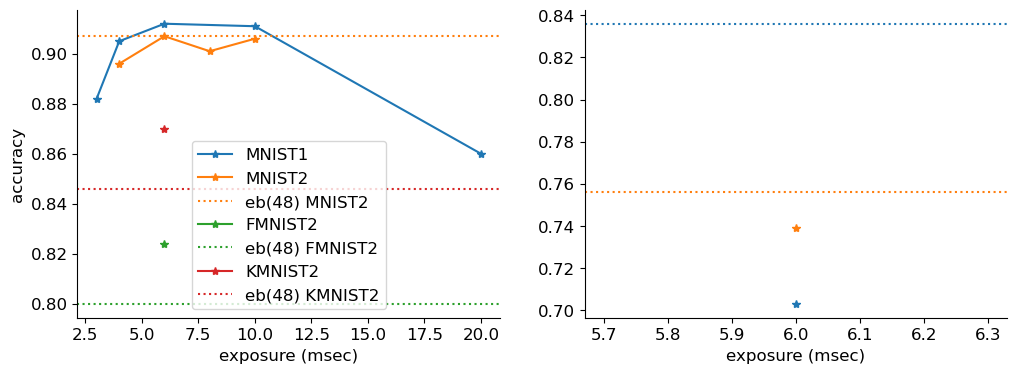

In [31]:
plt.figure(figsize=(12,4))
plt.rcParams.update({'font.size': 12})

eb_baseline_n_events = 48

styles = [':','--','.-']
# these_ds = dfsum['Dataset'].unique()
these_ds = ['MNIST','FMNIST','KMNIST']
for aaa, this_ds in enumerate(these_ds):
    sub_df = dfsum.loc[dfsum['Dataset']==this_ds]
    ddd = sorted(sub_df['Distance'].unique())
#     ddd = ['D1']
    for dd_,this_dist in enumerate(ddd):
        plt.subplot(1,2,dd_+1)
        uu = sub_df.loc[sub_df['Distance']==this_dist]
    
        configs = sorted(uu['Config'].unique())
        for this_config in configs:
            
            uuu = uu.loc[uu['Config']==this_config]
            eb_baseline = uuu.loc[np.logical_and(uuu['Exposure']==0.0, uuu['EventsNum']==eb_baseline_n_events)]
            uuu = uuu.loc[uuu['Exposure']!=0.0]
            
            color = plt.gca()._get_lines.get_next_color()  # Get the next color from the color cycle

            plt.plot(uuu['Exposure'].astype(float).to_numpy(),uuu['AccMean'].astype(float).to_numpy(),'-*',
                 color=color,label=this_ds+str(this_config))
#         fb_baseline = frames_LUT[(this_ds,this_dist)]
#         plt.plot(aaa*3+uu['n_events'].astype(float).to_numpy(),fb_baseline+0*uu['AccMean'].astype(float).to_numpy(),
#                  ':', linewidth=2,
#                  color=color)
            
            
            if eb_baseline['AccMean'].size > 0:
                plt.axhline(y=eb_baseline['AccMean'].astype(float).to_numpy(), color=color, linestyle=':', 
                        label='eb(48) '+this_ds+str(this_config)) 

        plt.xlabel('exposure (msec)')
#         plt.ylim(0.5,1.0)

        ax = plt.gca()
        ax.spines[['right', 'top']].set_visible(False)

plt.legend()
ax = plt.gca()
# ax.spines[['left','right', 'top']].set_visible(False)

# plt.yticks([0.5,1])
plt.subplot(1,2,1)
plt.ylabel('accuracy')
ax = plt.gca()

# add_inset_with_symbols(ax, width="15%", height="15%", loc=4, styles=['k-*','k:'], 
#                        titles = ['event based', 'frame based baseline'] ,
#                        bbox=(0.25,0.15,0.5,0.5))


In [27]:
# print(this_config)
# print(eb_baseline)
# uuu = sub_df.loc[sub_df['Config']==this_config]
ddd

['D1']

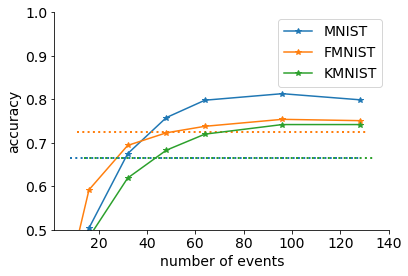

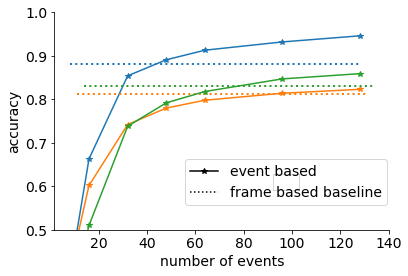

In [38]:
plt.figure(1,figsize=(6,4))
plt.rcParams.update({'font.size': 14})

plt.figure(2,figsize=(6,4))
plt.rcParams.update({'font.size': 14})

styles = [':','--','.-']
# these_ds = dfsum['Dataset'].unique()
these_ds = ['MNIST','FMNIST','KMNIST']
for aaa, this_ds in enumerate(these_ds):
    sub_df = dfsum.loc[dfsum['Dataset']==this_ds]
    ddd = sorted(sub_df['Distance'].unique())
    for dd,this_dist in enumerate(ddd):
        plt.figure(dd+1)
        uu = sub_df.loc[sub_df['Distance']==this_dist]
        
        color = plt.gca()._get_lines.get_next_color()  # Get the next color from the color cycle

        plt.plot(uu['n_events'].astype(float).to_numpy(),uu['AccMean'].astype(float).to_numpy(),'-*',
                 color=color,label=this_ds)
        fb_baseline = frames_LUT[(this_ds,this_dist)]
        plt.plot(aaa*3+uu['n_events'].astype(float).to_numpy(),fb_baseline+0*uu['AccMean'].astype(float).to_numpy(),
                 ':', linewidth=2,
                 color=color)

        plt.xlabel('number of events')
        plt.ylabel('accuracy')       
        plt.ylim(0.5,1.0)
        ax = plt.gca()

        ax.spines[['right', 'top']].set_visible(False)

plt.figure(2)

plt.legend(loc=1)
ax = plt.gca()
# ax.spines[['left','right', 'top']].set_visible(False)

# plt.yticks([0.5,1])
# plt.subplot(1,2,1)
plt.ylabel('accuracy')

plt.figure(1)
ax = plt.gca()

add_inset_with_symbols(ax, width="15%", height="15%", loc=4, styles=['k-*','k:'], 
                       titles = ['event based', 'frame based baseline'] ,
                       bbox=(0.25,0.15,0.5,0.5))

In [39]:
dfsum.loc[dfsum['Dataset']=='FMNIST']

,Dataset,Distance,n_events,AccMean,AccStd,AccCnt,AccSem,Date
22,FMNIST,D2,8,0.404,0.003,5.000,0.002,20240728
15,FMNIST,D1,8,0.405,0.003,5.000,0.001,20240801
21,FMNIST,D2,16,0.592,0.002,5.000,0.001,20240728
14,FMNIST,D1,16,0.602,0.002,4.000,0.001,20240801
17,FMNIST,D1,32,0.742,0.001,4.000,0.000,20240801
24,FMNIST,D2,32,0.694,0.002,5.000,0.001,20240728
19,FMNIST,D1,48,0.780,0.002,5.000,0.001,20240801
26,FMNIST,D2,48,0.723,0.002,5.000,0.001,20240728
23,FMNIST,D2,64,0.738,0.003,5.000,0.001,20240728
16,FMNIST,D1,64,0.798,0.001,5.000,0.000,20240801


In [40]:
dfsum.loc[:,dfsum.columns != 'Date']

,Dataset,Distance,n_events,AccMean,AccStd,AccCnt,AccSem
1,MNIST,D1,8,0.396,0.002,4.000,0.001
29,KMNIST,D1,8,0.333,0.001,5.000,0.001
22,FMNIST,D2,8,0.404,0.003,5.000,0.002
36,KMNIST,D2,8,0.301,0.004,5.000,0.002
15,FMNIST,D1,8,0.405,0.003,5.000,0.001
8,MNIST,D2,8,0.305,0.000,1.000,nan
0,MNIST,D1,16,0.663,0.003,5.000,0.001
28,KMNIST,D1,16,0.510,0.001,5.000,0.000
21,FMNIST,D2,16,0.592,0.002,5.000,0.001
14,FMNIST,D1,16,0.602,0.002,4.000,0.001


In [41]:
dfsum[['Dataset', 'Distance', 'n_events', 'AccCnt','AccMean','AccStd','AccSem' ]]

,Dataset,Distance,n_events,AccCnt,AccMean,AccStd,AccSem
1,MNIST,D1,8,4.000,0.396,0.002,0.001
29,KMNIST,D1,8,5.000,0.333,0.001,0.001
22,FMNIST,D2,8,5.000,0.404,0.003,0.002
36,KMNIST,D2,8,5.000,0.301,0.004,0.002
15,FMNIST,D1,8,5.000,0.405,0.003,0.001
8,MNIST,D2,8,1.000,0.305,0.000,nan
0,MNIST,D1,16,5.000,0.663,0.003,0.001
28,KMNIST,D1,16,5.000,0.510,0.001,0.000
21,FMNIST,D2,16,5.000,0.592,0.002,0.001
14,FMNIST,D1,16,4.000,0.602,0.002,0.001


In [42]:
import pandas as pd

def df_to_latex_table(df: pd.DataFrame, new_column_names: dict = None, column_formats: dict = None, default_format: str = ".3f") -> str:
    """
    Convert a pandas DataFrame to a LaTeX table string with optional column renaming, formatting, and multi-line headers.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        new_column_names (dict, optional): A dictionary to rename columns. 
                                           Format: {'old_name': 'new_name'}.
        column_formats (dict, optional): A dictionary specifying format for columns.
                                         Format: {'column_name': 'format_specifier'}.
                                         Example: {'A': '.2f', 'B': 'd'}.
        default_format (str, optional): Default formatting for numeric values. Defaults to '.3f'.
                                           
    Returns:
        str: Full LaTeX code for the table.
    """
    def try_convert_to_number(value):
        """Try to convert a value to a number if it looks like one."""
        try:
            return float(value) if '.' in str(value) else int(value)
        except ValueError:
            return value

    def format_header(header):
        """Format a column header to split long text into multiple lines using \makecell."""
        return "\\makecell{" + " \\\\ ".join(header.split()) + "}"

    # Rename columns if new_column_names is provided
    if new_column_names:
        df = df.rename(columns=new_column_names)
    
    # Apply formatting to columns if column_formats is provided
    formatted_df = df.copy()
    for col in formatted_df.columns:
        if column_formats and col in column_formats:
            fmt = column_formats[col]
        else:
            fmt = default_format  # Use default format for unspecified columns
        
        formatted_df[col] = formatted_df[col].apply(
            lambda x: f"{try_convert_to_number(x):{fmt}}" 
                      if pd.notnull(x) and isinstance(try_convert_to_number(x), (int, float)) 
                      else x
        )
    
    # Start the LaTeX table
    latex_code = "\\begin{table}[ht]\n\\centering\n"
    latex_code += "\\begin{tabular}{" + " | ".join(["c"] * len(formatted_df.columns)) + "}\n"
    latex_code += "\\hline\n"
    
    # Add column headers with multi-line formatting
    formatted_headers = [format_header(header) for header in formatted_df.columns]
    latex_code += " & ".join(formatted_headers) + " \\\\\n"
    latex_code += "\\hline\n"
    
    # Add rows
    for _, row in formatted_df.iterrows():
        latex_code += " & ".join(map(str, row)) + " \\\\\n"
        latex_code += "\\hline\n"
    
    # End the LaTeX table
    latex_code += "\\end{tabular}\n"
    latex_code += "\\caption{Your table caption here.}\n"
    latex_code += "\\label{tab:your_label_here}\n"
    latex_code += "\\end{table}"
    
    return latex_code


In [43]:
print(
    df_to_latex_table(dfsum[['Dataset', 'Distance', 'n_events', 'AccCnt','AccMean','AccStd','AccSem' ]],
                     column_formats={'AccCnt':'.0f'})
)

\begin{table}[ht]
\centering
\begin{tabular}{c | c | c | c | c | c | c}
\hline
\makecell{Dataset} & \makecell{Distance} & \makecell{n_events} & \makecell{AccCnt} & \makecell{AccMean} & \makecell{AccStd} & \makecell{AccSem} \\
\hline
MNIST & D1 & 8.000 & 4 & 0.396 & 0.002 & 0.001 \\
\hline
KMNIST & D1 & 8.000 & 5 & 0.333 & 0.001 & 0.001 \\
\hline
FMNIST & D2 & 8.000 & 5 & 0.404 & 0.003 & 0.002 \\
\hline
KMNIST & D2 & 8.000 & 5 & 0.301 & 0.004 & 0.002 \\
\hline
FMNIST & D1 & 8.000 & 5 & 0.405 & 0.003 & 0.001 \\
\hline
MNIST & D2 & 8.000 & 1 & 0.305 & 0.000 & nan \\
\hline
MNIST & D1 & 16.000 & 5 & 0.663 & 0.003 & 0.001 \\
\hline
KMNIST & D1 & 16.000 & 5 & 0.510 & 0.001 & 0.000 \\
\hline
FMNIST & D2 & 16.000 & 5 & 0.592 & 0.002 & 0.001 \\
\hline
FMNIST & D1 & 16.000 & 4 & 0.602 & 0.002 & 0.001 \\
\hline
KMNIST & D2 & 16.000 & 5 & 0.483 & 0.002 & 0.001 \\
\hline
MNIST & D2 & 16.000 & 5 & 0.504 & 0.004 & 0.002 \\
\hline
FMNIST & D1 & 32.000 & 4 & 0.742 & 0.001 & 0.000 \\
\hline
KMNIST & D2 